# ECCO Vrs 4

Estimating the Circulation and Climate of the Ocean (ECCO) uses the MITgcm earth model and "assimilates" millions of real-world observations—including satellite data (altimetry), Argo floats, and ship-based measurements. This creates a 3D reconstruction of the ocean.

Version 4 (1992-2018) is on NASA EarthData. There are many products in ECCO. We will look at 3 products on the 0.5 degree grid.

* ECCO_L4_MIXED_LAYER_DEPTH_05DEG_DAILY_V4R4: mixed layer depth
* ECCO_L4_SSH_05DEG_DAILY_V4R4: sea surface height
* ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4: this has temperature and salinity at depths.

*Note: In a virtual machine in AWS us-west-2, where NASA cloud data is, the point matchups are fast. In Colab, say, your compute is not in the same data region nor provider, and the same matchups might take 10x longer.*

## Prerequisites

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [ ]:
# if needed
pip install point-collocation

In [1]:
import earthaccess
earthaccess.login()

## Let's see what ECCO collections are available

In [10]:
import earthaccess
results = earthaccess.search_datasets(
    project = 'ECCO',
)
for item in results[0:10]:
    summary = item.summary()
    print(summary["short-name"])

ECCO_L4_ANCILLARY_DATA_V4R4
ECCO_L4_ATM_STATE_05DEG_DAILY_V4R4
ECCO_L4_ATM_STATE_LLC0090GRID_DAILY_V4R4
ECCO_L4_ATM_STATE_05DEG_MONTHLY_V4R4
ECCO_L4_ATM_STATE_LLC0090GRID_MONTHLY_V4R4
ECCO_L4_OCEAN_BOLUS_STREAMFUNCTION_LLC0090GRID_DAILY_V4R4
ECCO_L4_OCEAN_BOLUS_STREAMFUNCTION_LLC0090GRID_MONTHLY_V4R4
ECCO_L4_BOLUS_05DEG_DAILY_V4R4
ECCO_L4_BOLUS_LLC0090GRID_DAILY_V4R4
ECCO_L4_BOLUS_05DEG_MONTHLY_V4R4


## Get some sample points over the ocean

In [2]:
import pandas as pd
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/point-collocation/main/"
    "examples/fixtures/points_1000.csv"
)
df_points = pd.read_csv(
    url,
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year < 2018) &
    (df_points["time"].dt.year > 2014) &
    (df_points["land"] == False)
].reset_index(drop=True)
# Force all timestamps to noon UTC to avoid "midnight overlap" issues
df["time"] = df["time"].dt.normalize() + pd.Timedelta(hours=12)
print(len(df))
df.head()

52


,lat,lon,time,land
0,-2.175441,2.168506,2017-07-02 12:00:00,False
1,-16.216691,76.119033,2015-04-16 12:00:00,False
2,8.500092,82.677680,2015-07-21 12:00:00,False
3,-32.290881,-136.206453,2017-08-09 12:00:00,False
4,-29.495688,-145.182846,2016-02-10 12:00:00,False


## Let's plot the points

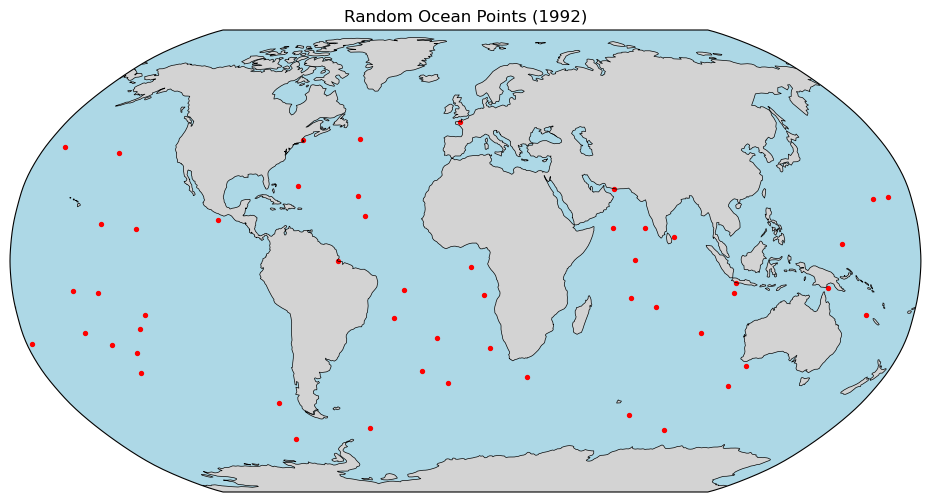

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# create Robinson projection
proj = ccrs.Robinson()

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=proj)

# add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# plot points
ax.scatter(
    df["lon"],
    df["lat"],
    s=8,
    color="red",
    transform=ccrs.PlateCarree()
)

ax.set_global()
plt.title("Random Ocean Points (1992)")
plt.show()

## Daily Sea Surface Height

### Create the granule plan

In [2]:
import point_collocation as pc
short_name="ECCO_L4_SSH_05DEG_DAILY_V4R4"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary(n=2)

Plan: 52 points → 52 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 2 point(s):
  [0] lat=-2.1754, lon=2.1685, time=2017-07-02 12:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_DAILY_V4R4/SEA_SURFACE_HEIGHT_day_mean_2017-07-02_ECCO_V4r4_latlon_0p50deg.nc
  [1] lat=-16.2167, lon=76.1190, time=2015-04-16 12:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_DAILY_V4R4/SEA_SURFACE_HEIGHT_day_mean_2015-04-16_ECCO_V4r4_latlon_0p50deg.nc


In [4]:
# If needed we can look at the granule metadata
plan.results[0:1]

[Collection: {'Version': 'V4r4', 'ShortName': 'ECCO_L4_SSH_05DEG_DAILY_V4R4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180, 'SouthBoundingCoordinate': -90, 'EastBoundingCoordinate': 180, 'NorthBoundingCoordinate': 90}]}}}
 Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2015-01-12T00:00:00.000Z', 'BeginningDateTime': '2015-01-11T00:00:00.000Z'}}
 Size(MB): 0.9840011596679688
 Data: ['https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_SSH_05DEG_DAILY_V4R4/SEA_SURFACE_HEIGHT_day_mean_2015-01-11_ECCO_V4r4_latlon_0p50deg.nc']]

## Let's plot a granule to see how it looks

In [3]:
ds = plan.open_dataset(0)
ds

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',)


<xarray.Dataset> Size: 3MB
Dimensions:         (time: 1, latitude: 360, longitude: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 8B 2015-01-11T12:00:00
  * latitude        (latitude) float32 1kB -89.75 -89.25 -88.75 ... 89.25 89.75
  * longitude       (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (latitude, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (longitude, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    SSH             (time, latitude, longitude) float32 1MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SSHIBC          (time, latitude, longitude) float32 1MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SSHNOIBC        (time, latitude, longitude) float32 1MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on a regular lat-lon grid. ...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1D
    time_coverage_end:            2015-01-12T00:00:00
    time_coverage_resolution:     P1D
    time_coverage_start:          2015-01-11T00:00:00
    title:                        ECCO Sea Surface Height - Daily Mean 0.5 De...
    uuid:                         4f9bf9bc-404a-11eb-93e8-0cc47a3f39b7

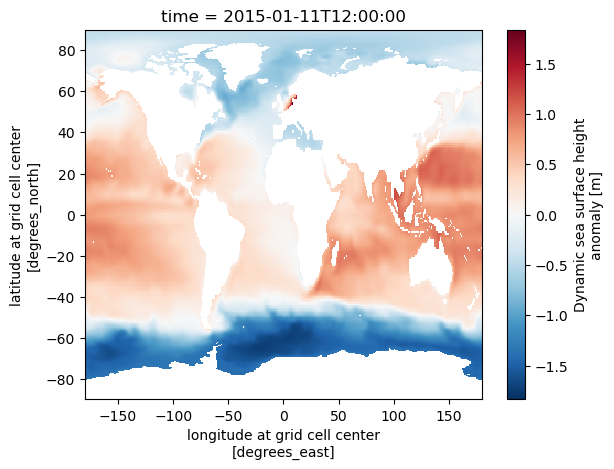

In [4]:
ds.SSH.plot()

## Get the matchups

In [4]:
%%time
res = pc.matchup(plan, variables = ["SSH"])

CPU times: user 12.3 s, sys: 97.6 ms, total: 12.4 s
Wall time: 17.5 s


In [5]:
res[['lat', 'lon', 'time', 'SSH']].dropna(subset=['SSH']).head()

,lat,lon,time,SSH
0,-2.175441,2.168506,2017-07-02 12:00:00,0.049727
1,-16.216691,76.119033,2015-04-16 12:00:00,0.795746
2,8.500092,82.677680,2015-07-21 12:00:00,0.555195
3,-32.290881,-136.206453,2017-08-09 12:00:00,0.471952
4,-29.495688,-145.182846,2016-02-10 12:00:00,0.597943


## Temperature

Temperature is 3D: lat, lon, depth. We will add depth to our dataframe so we can get temperature at specific depths. Depth is `Z` in ECCO granules and it is negative. We need to specify the additional coordinate that we are matching, beyond lat, lon, time.

In [6]:
df['depth'] = -1000

coord_spec = {
  "additional": {
    "depth": {"source": "Z", "points": "depth"},
  },
}

In [7]:
import point_collocation as pc
short_name="ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary(n=2)

Plan: 52 points → 52 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 2 point(s):
  [0] lat=-2.1754, lon=2.1685, time=2017-07-02 12:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/OCEAN_TEMPERATURE_SALINITY_day_mean_2017-07-02_ECCO_V4r4_latlon_0p50deg.nc
  [1] lat=-16.2167, lon=76.1190, time=2015-04-16 12:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4/OCEAN_TEMPERATURE_SALINITY_day_mean_2015-04-16_ECCO_V4r4_latlon_0p50deg.nc


In [8]:
ds = plan.open_dataset(0)
ds

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',); time dim='time' (1 step(s))
Points columns used: y='lat', x='lon', time='time'


<xarray.Dataset> Size: 104MB
Dimensions:         (time: 1, Z: 50, latitude: 360, longitude: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 8B 2015-01-11T12:00:00
  * Z               (Z) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * latitude        (latitude) float32 1kB -89.75 -89.25 -88.75 ... 89.25 89.75
  * longitude       (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (latitude, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (longitude, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
    Z_bnds          (Z, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    THETA           (time, Z, latitude, longitude) float32 52MB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
    SALT            (time, Z, latitude, longitude) float32 52MB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on a regular lat-lon gri...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2015-01-12T00:00:00
    time_coverage_resolution:        P1D
    time_coverage_start:             2015-01-11T00:00:00
    title:                           ECCO Ocean Temperature and Salinity - Da...
    uuid:                            a8d2856a-412a-11eb-ba7a-0cc47a3f6879

### Get the matchups for potential temperature

They with be 3D. Variable at 50 depths. `THETA` is temperature at -1000 meters, which is the depth value in our dataframe.

In [9]:
%%time
res = pc.matchup(plan, variables = ["THETA"], coord_spec=coord_spec)

CPU times: user 17.5 s, sys: 1.04 s, total: 18.5 s
Wall time: 43.5 s


In [12]:
res[['lat', 'lon', 'time', 'depth', 'THETA']].head()

,lat,lon,time,depth,THETA
0,-2.175441,2.168506,2017-07-02 12:00:00,-1000,4.333574
1,-16.216691,76.119033,2015-04-16 12:00:00,-1000,5.358678
2,8.500092,82.677680,2015-07-21 12:00:00,-1000,6.668801
3,-32.290881,-136.206453,2017-08-09 12:00:00,-1000,4.466073
4,-29.495688,-145.182846,2016-02-10 12:00:00,-1000,4.450537


## Mixed Layer Depth

Mixed Layer Depth (MLD) is the thickness of the uppermost layer of the ocean where the water properties (temperature, salinity, and density) are nearly uniform with depth and mixed by wind. Below the MLD is the thermocline, between the MLD and roughly 1,000m, the temperature rapidly drops and density increases. Below the thermocline is the deep ocean, which is cold and dense.

In [10]:
import point_collocation as pc
short_name="ECCO_L4_MIXED_LAYER_DEPTH_05DEG_DAILY_V4R4"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary(n=2)

Plan: 52 points → 52 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 2 point(s):
  [0] lat=-2.1754, lon=2.1685, time=2017-07-02 12:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_MIXED_LAYER_DEPTH_05DEG_DAILY_V4R4/OCEAN_MIXED_LAYER_DEPTH_day_mean_2017-07-02_ECCO_V4r4_latlon_0p50deg.nc
  [1] lat=-16.2167, lon=76.1190, time=2015-04-16 12:00:00: 1 match(es)
    → https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/ECCO_L4_MIXED_LAYER_DEPTH_05DEG_DAILY_V4R4/OCEAN_MIXED_LAYER_DEPTH_day_mean_2015-04-16_ECCO_V4r4_latlon_0p50deg.nc


In [11]:
ds = plan.open_dataset(0)
ds

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('longitude', 'latitude') — lon dims=('longitude',), lat dims=('latitude',)


<xarray.Dataset> Size: 1MB
Dimensions:         (time: 1, latitude: 360, longitude: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 8B 2015-01-11T12:00:00
  * latitude        (latitude) float32 1kB -89.75 -89.25 -88.75 ... 89.25 89.75
  * longitude       (longitude) float32 3kB -179.8 -179.2 -178.8 ... 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (latitude, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (longitude, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    MXLDEPTH        (time, latitude, longitude) float32 1MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on a regular lat-lon grid. ...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1D
    time_coverage_end:            2015-01-12T00:00:00
    time_coverage_resolution:     P1D
    time_coverage_start:          2015-01-11T00:00:00
    title:                        ECCO Ocean Mixed Layer Depth - Daily Mean 0...
    uuid:                         7ce9f68c-4052-11eb-bc70-0cc47a3f3a7f

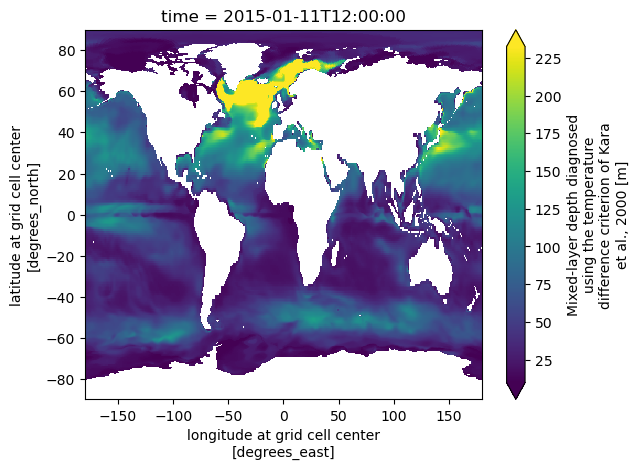

In [12]:
ds.MXLDEPTH.plot(robust=True)

### Get matchups

In [13]:
%%time
res = pc.matchup(plan, variables = ["MXLDEPTH"])

CPU times: user 11.7 s, sys: 73.8 ms, total: 11.8 s
Wall time: 17.3 s


In [14]:
res[['lat', 'lon', 'time', 'MXLDEPTH']].dropna(subset=['MXLDEPTH']).head()

,lat,lon,time,MXLDEPTH
0,-2.175441,2.168506,2017-07-02 12:00:00,18.219427
1,-16.216691,76.119033,2015-04-16 12:00:00,38.249325
2,8.500092,82.677680,2015-07-21 12:00:00,38.327206
3,-32.290881,-136.206453,2017-08-09 12:00:00,117.164932
4,-29.495688,-145.182846,2016-02-10 12:00:00,21.410013
